## Home Task: Implement K-means algorithm

### Data

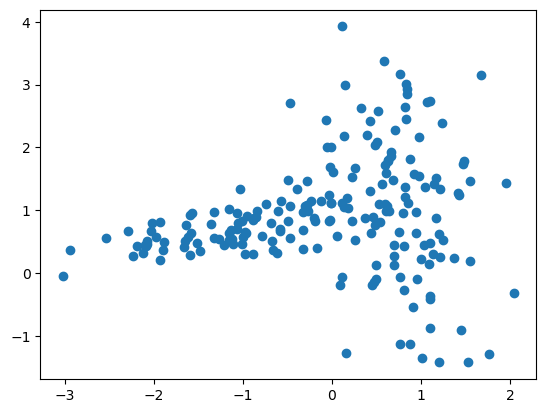

In [3]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt 
import numpy as np
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

#### 1. Initialize K centroids

функції для ініціалізації та візуалізації центроїдів (координати підібрав візуально)

In [4]:
points = Xc_2 
colors = np.array(['green', 'orange', 'blue', 'red'])

def init_centroids(amount, is_random = True, points = None, seed = 10): 
    if is_random:
        np.random.seed(seed) 
        return points[np.random.choice(len(points), amount)]        
    else:
        centroids = np.array ([[-1.5, 0.5], [0.5, 2.5], [1, 0]])
        return centroids[:amount]


k = 3
centroids = init_centroids(k, is_random=False)

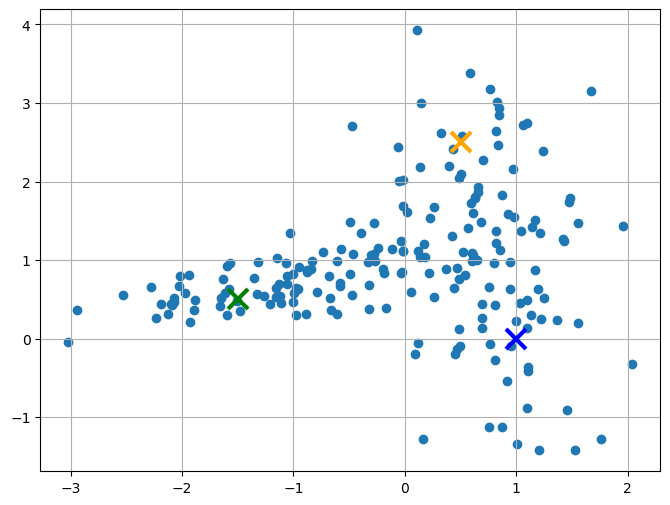

In [5]:
def plot_points(closest_centroids = None):
    if closest_centroids is None:
        plt.scatter(points[:,0], points[:,1])
    else:
        plt.scatter(points[:,0], points[:,1], c=colors[closest_centroids])

def plot_centroids(centroids):
    for i, c in enumerate (centroids):
        plt.plot(c[0], c[1], marker = 'x', color= colors[i], markersize=14, markeredgewidth=3) 

def draw_state(centroids = None, closest_centroids = None):        
    plt.figure(figsize=(8, 6))
    plot_points(closest_centroids)
    plot_centroids(centroids)
    plt.grid(True)
    plt.show()

draw_state(centroids = centroids, closest_centroids=None)

#### 2. Assign every point to closest centroid

функції для обчислення відстаней та пошуку найблищого центроїда

In [6]:
def compute_distances(samples, centroids):
    '''
    params:
        samples - масив зразків (координати точок)
        centroids - масив координат центроїдів
    returns: 2D масив відстаней від кожного зразка до кожного центроїда
    '''    
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples-c) for c in centroids])

def compute_closest_centroids(centroids):       
    all_distances = compute_distances(points, centroids) 
    
    closest_centroids = np.apply_along_axis(np.argmin, 0, all_distances)
    return closest_centroids

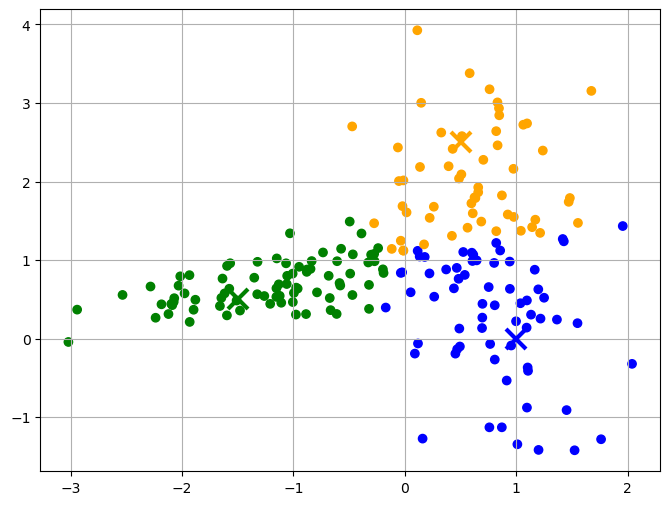

In [7]:
closest_centroids = compute_closest_centroids(centroids)

draw_state(centroids = centroids, closest_centroids = closest_centroids)

#### 3. Compute new centroids as means of samples assigned to corresponding centroid

функція перерахунку центроїдів

In [8]:
def compute_means(centroids, closest_centroids):     
    new_centroids = []
    
    for i in range(len(centroids)):
        if i not in closest_centroids: 
            new_centroids.append(centroids[i])
        else: 
            new_centroid = np.mean(points[np.where(closest_centroids == i)], axis = 0)
            new_centroids.append(new_centroid)
            
    return new_centroids

нові центроїди, візуалізація першої ітерації

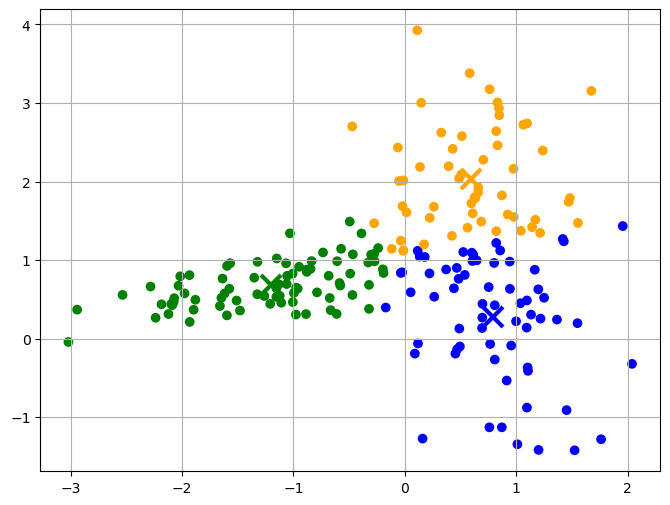

In [9]:
centroids = compute_means(centroids, closest_centroids)
draw_state(centroids = centroids, closest_centroids = closest_centroids)

#### 4. Implement cost $J = \frac{1}{m}\underset{i}{\sum}(d^{(i)})^{2}$ where $d^{(i)}$ is distance from sample $x^{(i)}$ to assigned centroid $c^{(i)}$

реалізація функції  "J"

In [10]:
def J(centroids, closest_centroids):
    '''
    params: 
        centroids - список координат центроїдів
        closest_centroids - масив індексів (якій точці який центроїд належить)
    '''
    all_dist = [] 
    
    for c_index in set(closest_centroids):
        assigned_samples = points[np.where(closest_centroids == c_index)]
        
        all_dist_centroid = compute_distances(assigned_samples, [centroids[c_index]])
        
        all_dist.append(np.sum(all_dist_centroid))
    
    m = len(closest_centroids)
    
    return 1/m * np.sum(all_dist)

In [12]:
cost = J(centroids, closest_centroids)

print(f"Поточний cost = {cost:.4f}")

Поточний cost = 0.7107


#### 5. Iterate setps 2,3 till cost is stabile

функція повного циклу алгоритму

In [14]:
def run_k_means(initial_centroids):
    centroids = initial_centroids
    is_first_time = True 
    J_hist = []
    is_to_continue = True
    
    while is_to_continue:
        closest_centroids = compute_closest_centroids(centroids) 
        centroids = compute_means(centroids, closest_centroids) 
        new_J = J(centroids, closest_centroids)                
        if is_first_time:
            J_hist.append(new_J)            
            is_first_time = False
            continue
        if J_hist[-1] == new_J:
            is_to_continue = False
        else: 
            J_hist.append(new_J)         

    return centroids, closest_centroids, J_hist

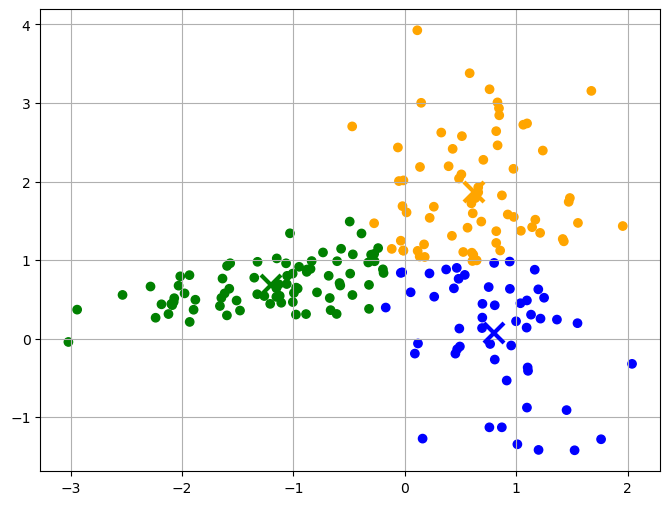

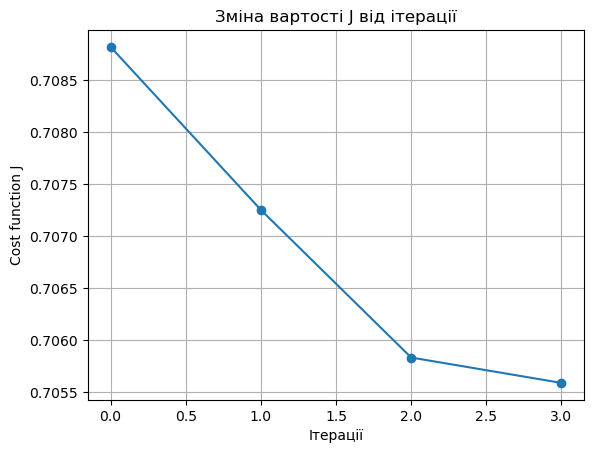

In [16]:
final_centroids, final_closest_centroids, J_history = run_k_means(centroids)

draw_state(centroids = final_centroids, closest_centroids = final_closest_centroids)

plt.figure()
plt.plot(J_history, marker='o')
plt.title('Зміна вартості J від ітерації')
plt.xlabel('Ітерації')
plt.ylabel('Cost function J')
plt.grid(True)
plt.show()

#### 6. Select the best clustering (with the least cost) from 100 results computed with random centroid initializations

In [29]:
best_result = []
k = 4

for random_iter in range (100):  
    initial_centroids = init_centroids(amount=k, is_random=True, points=points, seed=None)
    
    current_centroids, current_closest_centroids, current_J_hist = run_k_means(initial_centroids)
    
    current_final_J = current_J_hist[-1]
    
    if len(best_result) == 0 or current_final_J < best_result[2]:
        best_result = [current_centroids, current_closest_centroids, current_final_J]

print(f"Найкращий cost J = {best_result[2]:.4f}")

Найкращий cost J = 0.5997


#### 7. Visualize results (clusters, centroids) for K = 4

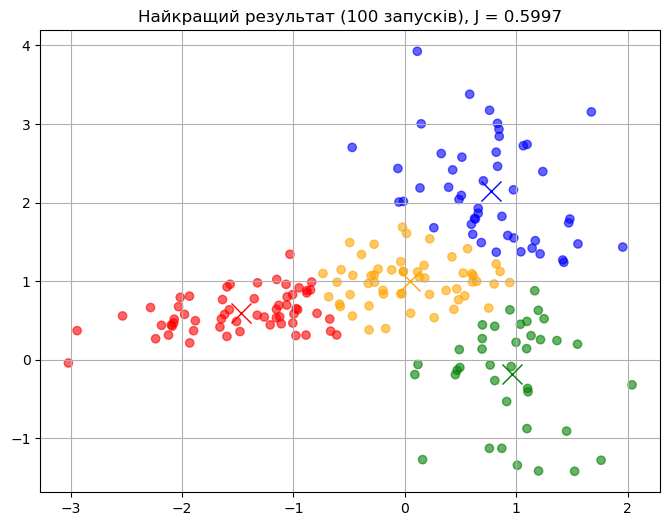

In [30]:
best_centroids = best_result[0]
best_labels = best_result[1]
best_cost = best_result[2]

plt.figure(figsize=(8, 6))
plt.scatter(points[:,0], points[:,1], c=colors[best_labels], alpha=0.6)

for i, c in enumerate(best_centroids):
    plt.plot(c[0], c[1], marker='x', color=colors[i], markersize=14)

plt.title(f'Найкращий результат (100 запусків), J = {best_cost:.4f}')
plt.grid(True)
plt.show()